# One Problem, Three Gradient Descents: Batch, Mini-Batch & Stochastic

Every flavour of gradient descent runs the *same* loop:

> predict → measure error → compute the gradient of the cost → step the parameters downhill → repeat.

The **only** thing that changes between **batch**, **mini-batch**, and **stochastic**
gradient descent is **how many training rows are used to compute the gradient for a
single parameter update**:

| Variant | Rows per update | Updates per epoch (N rows) |
|---|---|---|
| **Batch** (full-batch) | all N | 1 |
| **Mini-batch** | a small chunk B (e.g. 32) | ⌈N / B⌉ |
| **Stochastic (SGD)** | exactly 1 | N |

This notebook takes **a single regression problem** and runs all three on it with the
**same model, same learning rate $\alpha$, same initial parameters $\theta=(0,0)$, same
loss function** — so every difference you see is caused purely by the batch size.

(One thing we deliberately do **not** hold equal is the number of epochs. Batch GD
takes one step per epoch and needs many passes; SGD takes N steps per epoch and gets
near the answer in a *fraction* of one pass. Forcing "same epochs" would just make
whichever variant you picked the epoch count for look good. Instead each variant runs
long enough to converge — or, for constant-$\alpha$ SGD, long enough to show that it
*doesn't* fully settle — and we compare **how** each one gets there: per parameter
update, per second, and along its path on the loss surface.)

It has two parts:

1. **A hand-computable exam-style problem** — one gradient step of each variant on a
   6-row dataset, with a step-marked solution and marking rubric.
2. **A visual comparison** on real data (California Housing, 20,640 rows) — convergence
   curves, parameter trajectories on the loss surface, and a cost/speed table.

## Notation and the cost/gradient convention used everywhere in this notebook

Model (one feature, two parameters):

$$\hat{y} = \theta_0 + \theta_1 x$$

Cost over a set of $m$ rows (the **$\tfrac{1}{2m}$** convention — same as the course
demo `CS_3_ML_Linear_Regression_Using_Gradient_Descent`):

$$J(\theta) \;=\; \frac{1}{2m} \sum_{i=1}^{m} \bigl(y^{(i)} - \hat{y}^{(i)}\bigr)^2$$

Gradient (with $x_0^{(i)} = 1$ for the intercept):

$$\frac{\partial J}{\partial \theta_j} \;=\; -\frac{1}{m} \sum_{i=1}^{m} \bigl(y^{(i)} - \hat{y}^{(i)}\bigr)\, x_j^{(i)}$$

Update rule ($\alpha$ = learning rate):

$$\theta_j \;\leftarrow\; \theta_j \;-\; \alpha \, \frac{\partial J}{\partial \theta_j}
\;=\; \theta_j \;+\; \frac{\alpha}{m} \sum_{i=1}^{m} \bigl(y^{(i)} - \hat{y}^{(i)}\bigr)\, x_j^{(i)}$$

> **The one rule that keeps the comparison fair:** $m$ is the number of rows in **the
> batch used for that one update** — $m = N$ for batch, $m = B$ for mini-batch, $m = 1$
> for SGD. The gradient is always **averaged** (the $\tfrac{1}{m}$), never summed. If you
> sum instead of average, a bigger batch produces a bigger step, and "same $\alpha$ for
> all three" stops meaning anything.

---
# Part 1 — Exam-style problem: one step of each variant *by hand* [6 marks]

An analyst models weekly **sales** $y$ (₹ lakh) against **advertising spend** $x$
(₹ lakh) with a linear model $\hat{y} = \theta_0 + \theta_1 x$, trained by gradient
descent using the $\tfrac{1}{2m}$ cost convention above.

The full training set has just **6 rows**:

| row id | $x$ (spend) | $y$ (sales) |
|---|---|---|
| 1 | 1 | 3 |
| 2 | 2 | 3 |
| 3 | 3 | 5 |
| 4 | 4 | 6 |
| 5 | 5 | 6 |
| 6 | 6 | 7 |

Initial parameters $\theta = (\theta_0, \theta_1) = (0,\ 0)$; learning rate
$\alpha = 0.1$. For the stochastic and mini-batch parts, the shuffled row order for
this epoch is **[3, 1, 5, 2, 6, 4]**.

**(a) [2]** Perform **one full-batch** gradient-descent update (all 6 rows). Show
$\sum (y-\hat{y})$, $\sum (y-\hat{y})x$, both partial derivatives, and the updated
$\theta$.

**(b) [1.5]** Perform **one stochastic** update — i.e. the **first** update of the
epoch, which uses only the first row of the shuffled order.

**(c) [1.5]** Perform **one mini-batch** update with **batch size 2** — the first
mini-batch of the epoch (first two rows of the shuffled order).

**(d) [1]** The batch update in (a) does not depend on the shuffle order, but the SGD
update in (b) does. Explain why, and state how many parameter updates one full epoch
performs under each of the three variants for this 6-row dataset.

### Solution

All predictions start at $\hat{y} = 0 + 0\cdot x = 0$, so every residual
$r^{(i)} = y^{(i)} - \hat{y}^{(i)} = y^{(i)}$ on this first step.

**(a) Full-batch update — $m = 6$ [2 marks]**

$\sum_{i=1}^{6} (y-\hat{y}) = 3+3+5+6+6+7 = 30$ &nbsp;(✓ 0.5)

$\sum_{i=1}^{6} (y-\hat{y})\,x = 3(1)+3(2)+5(3)+6(4)+6(5)+7(6) = 3+6+15+24+30+42 = 120$ &nbsp;(✓ 0.5)

$\dfrac{\partial J}{\partial \theta_0} = -\dfrac{1}{6}(30) = -5$, &nbsp;
$\dfrac{\partial J}{\partial \theta_1} = -\dfrac{1}{6}(120) = -20$ &nbsp;(✓ 0.5)

$\theta_0 \leftarrow 0 - 0.1(-5) = \mathbf{0.5}$, &nbsp;
$\theta_1 \leftarrow 0 - 0.1(-20) = \mathbf{2.0}$ &nbsp;(✓ 0.5)

**(b) Stochastic update — first row of order [3,1,5,2,6,4] is row 3: $(x,y)=(3,5)$, $m=1$ [1.5 marks]**

$r = 5 - 0 = 5$ &nbsp;(✓ 0.5)

$\dfrac{\partial J}{\partial \theta_0} = -\dfrac{1}{1}(5) = -5$, &nbsp;
$\dfrac{\partial J}{\partial \theta_1} = -\dfrac{1}{1}(5)(3) = -15$ &nbsp;(✓ 0.5)

$\theta_0 \leftarrow 0 - 0.1(-5) = \mathbf{0.5}$, &nbsp;
$\theta_1 \leftarrow 0 - 0.1(-15) = \mathbf{1.5}$ &nbsp;(✓ 0.5)

**(c) Mini-batch update — first two rows of the order are rows 3 and 1: $(3,5)$ and $(1,3)$, $m=2$ [1.5 marks]**

$\sum (y-\hat{y}) = 5 + 3 = 8$; &nbsp; $\sum (y-\hat{y})\,x = 5(3) + 3(1) = 18$ &nbsp;(✓ 0.5)

$\dfrac{\partial J}{\partial \theta_0} = -\dfrac{1}{2}(8) = -4$, &nbsp;
$\dfrac{\partial J}{\partial \theta_1} = -\dfrac{1}{2}(18) = -9$ &nbsp;(✓ 0.5)

$\theta_0 \leftarrow 0 - 0.1(-4) = \mathbf{0.4}$, &nbsp;
$\theta_1 \leftarrow 0 - 0.1(-9) = \mathbf{0.9}$ &nbsp;(✓ 0.5)

**(d) Order-dependence and updates per epoch [1 mark]**

The batch gradient is a **sum over all 6 rows**; addition is commutative, so the
result is identical no matter what order the rows are visited — one batch step per
epoch sees the whole dataset at once. (✓ 0.5)

SGD updates $\theta$ **after every single row**, so the very first update depends on
*which* row is first; that changed $\theta$ then feeds into the second update, and so
on — a different shuffle produces a different sequence of updates and a different
end-of-epoch $\theta$. (✓ 0.25)

Updates in one epoch of this 6-row set: **batch = 1**, **mini-batch (B=2) =
⌈6/2⌉ = 3** (three batches, each exactly size 2), **stochastic = 6**. (✓ 0.25)

### Marking rubric

| Part | Step | Marks |
|---|---|---|
| (a) | $\sum(y-\hat y) = 30$ | 0.5 |
| | $\sum(y-\hat y)x = 120$ | 0.5 |
| | Both partials ($-5$, $-20$) | 0.5 |
| | Updated $\theta = (0.5,\ 2.0)$ | 0.5 |
| (b) | Identifies row 3 as first, $r = 5$ | 0.5 |
| | Partials ($-5$, $-15$) with $m=1$ | 0.5 |
| | Updated $\theta = (0.5,\ 1.5)$ | 0.5 |
| (c) | Correct 2 rows and sums ($8$, $18$) | 0.5 |
| | Partials ($-4$, $-9$) with $m=2$ | 0.5 |
| | Updated $\theta = (0.4,\ 0.9)$ | 0.5 |
| (d) | Batch invariant to order (sum is commutative) | 0.5 |
| | SGD compounds per-row updates → order matters | 0.25 |
| | Updates/epoch: 1 / 3 / 6 | 0.25 |

In [1]:
# --- Part 1 checked numerically: the code and the hand arithmetic must agree ---
import numpy as np

x = np.array([1., 2., 3., 4., 5., 6.])
y = np.array([3., 3., 5., 6., 6., 7.])
theta0, theta1, alpha = 0.0, 0.0, 0.1
order = [2, 0, 4, 1, 5, 3]          # rows [3,1,5,2,6,4] as 0-based indices


def gd_step(xs, ys, t0, t1, a):
    """One update using the rows in xs/ys. m = len(xs) -> the 1/2m convention."""
    m = len(xs)
    r = ys - (t0 + t1 * xs)                 # residuals y - yhat
    g0 = -(1.0 / m) * np.sum(r)             # dJ/dtheta0
    g1 = -(1.0 / m) * np.sum(r * xs)        # dJ/dtheta1
    return t0 - a * g0, t1 - a * g1, g0, g1


# (a) full batch - all 6 rows
a0, a1, g0, g1 = gd_step(x, y, theta0, theta1, alpha)
print(f"(a) batch      grads=({g0:+.2f}, {g1:+.2f})  ->  theta=({a0:.3f}, {a1:.3f})")
assert np.allclose([g0, g1, a0, a1], [-5.0, -20.0, 0.5, 2.0])

# (b) stochastic - first row of the shuffled order (row 3)
i = order[0]
b0, b1, g0, g1 = gd_step(x[[i]], y[[i]], theta0, theta1, alpha)
print(f"(b) stochastic grads=({g0:+.2f}, {g1:+.2f})  ->  theta=({b0:.3f}, {b1:.3f})")
assert np.allclose([g0, g1, b0, b1], [-5.0, -15.0, 0.5, 1.5])

# (c) mini-batch B=2 - first two rows of the shuffled order (rows 3, 1)
idx = order[:2]
c0, c1, g0, g1 = gd_step(x[idx], y[idx], theta0, theta1, alpha)
print(f"(c) mini-batch grads=({g0:+.2f}, {g1:+.2f})  ->  theta=({c0:.3f}, {c1:.3f})")
assert np.allclose([g0, g1, c0, c1], [-4.0, -9.0, 0.4, 0.9])

# (d) one full epoch of each -> number of parameter updates
def updates_per_epoch(n, batch_size):
    return len(range(0, n, batch_size))

print(f"\n(d) updates/epoch: batch={updates_per_epoch(6, 6)}, "
      f"mini-batch B=2={updates_per_epoch(6, 2)}, stochastic={updates_per_epoch(6, 1)}")
assert (updates_per_epoch(6, 6), updates_per_epoch(6, 2), updates_per_epoch(6, 1)) == (1, 3, 6)

print("\nAll hand-computed answers match the code.")

(a) batch      grads=(-5.00, -20.00)  ->  theta=(0.500, 2.000)
(b) stochastic grads=(-5.00, -15.00)  ->  theta=(0.500, 1.500)
(c) mini-batch grads=(-4.00, -9.00)  ->  theta=(0.400, 0.900)

(d) updates/epoch: batch=1, mini-batch B=2=3, stochastic=6

All hand-computed answers match the code.


---
# Part 2 — The real problem: California Housing

We now move to a real dataset so the *cost* and *speed* differences between the
variants become visible.

**Dataset:** California Housing (`ML/california_housing.csv`, derived once from
`sklearn.datasets.fetch_california_housing` so the notebook needs no network at run
time). It has 20,640 block-group rows from the 1990 US census. We use one feature:

- **`MedInc`** — median income in the block group (tens of thousands of USD)
- **target `MedHouseVal`** — median house value in the block group (hundreds of
  thousands of USD)

**Model:** $\widehat{\text{value}} = \theta_0 + \theta_1 \cdot \text{MedInc}$ — the
same two-parameter line as Part 1, just fit to 20k points instead of 5.

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

# california_housing.csv was generated once (needs internet only that one time) with:
#   from sklearn.datasets import fetch_california_housing
#   fetch_california_housing(as_frame=True).frame[["MedInc", "MedHouseVal"]].to_csv("california_housing.csv", index=False)
df = pd.read_csv("california_housing.csv")   # run this notebook from the ML/ folder
print(df.shape)
df.head()

(20640, 2)


,MedInc,MedHouseVal
0,8.3252,4.526
1,8.3014,3.585
2,7.2574,3.521
3,5.6431,3.413
4,3.8462,3.422


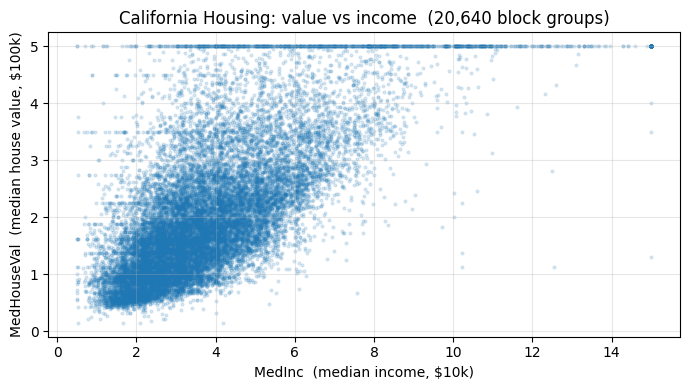

In [3]:
plt.figure(figsize=(7, 4))
plt.scatter(df["MedInc"], df["MedHouseVal"], s=4, alpha=0.15)
plt.xlabel("MedInc  (median income, $10k)")
plt.ylabel("MedHouseVal  (median house value, $100k)")
plt.title("California Housing: value vs income  (20,640 block groups)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Train/test split, then standardise on the **training** statistics only

We split first, then compute the mean/std on the **train** split and use them to
transform both splits. Fitting the scaler on the full dataset would leak test-set
information into training — exactly the mistake dissected in Question 1 of the
practice paper. Standardising also puts both parameters on a similar scale, so a
single learning rate works for both $\theta_0$ and $\theta_1$.

In [4]:
data = df.sample(frac=1.0, random_state=0).reset_index(drop=True)   # shuffle once
n_train = int(0.8 * len(data))

x_raw = data["MedInc"].to_numpy()
y_raw = data["MedHouseVal"].to_numpy()

x_tr_raw, x_te_raw = x_raw[:n_train], x_raw[n_train:]
y_tr_raw, y_te_raw = y_raw[:n_train], y_raw[n_train:]

# statistics from the TRAIN split only
x_mu, x_sd = x_tr_raw.mean(), x_tr_raw.std()
y_mu, y_sd = y_tr_raw.mean(), y_tr_raw.std()

x_tr = (x_tr_raw - x_mu) / x_sd
x_te = (x_te_raw - x_mu) / x_sd
y_tr = (y_tr_raw - y_mu) / y_sd
y_te = (y_te_raw - y_mu) / y_sd

N = len(x_tr)
print(f"train rows N = {N},  test rows = {len(x_te)}")

# closed-form optimum (standardised) for reference lines later
theta1_star = np.sum((x_tr - x_tr.mean()) * (y_tr - y_tr.mean())) / np.sum((x_tr - x_tr.mean())**2)
theta0_star = y_tr.mean() - theta1_star * x_tr.mean()
print(f"least-squares optimum (standardised):  theta0* = {theta0_star:.4f},  theta1* = {theta1_star:.4f}")

train rows N = 16512,  test rows = 4128
least-squares optimum (standardised):  theta0* = -0.0000,  theta1* = 0.6858


---
# Part 3 — One training loop, three batch sizes

The functions below use the **exact convention from the top of the notebook**. A
single `run_gd(batch_size=...)` drives all three variants:

- `batch_size = N` → **batch** GD (1 update / epoch)
- `batch_size = 32` → **mini-batch** GD (⌈N/32⌉ updates / epoch)
- `batch_size = 1` → **stochastic** GD (N updates / epoch)

Held identical across all three: `alpha`, the initial $\theta = (0, 0)$, the loss, and
the RNG seed that controls the per-epoch shuffle. Only `batch_size` — and, as explained
above, the number of `epochs` each one needs — differs.

In [5]:
def predict(x, theta):
    return theta[0] + theta[1] * x


def cost(x, y, theta):
    """(1/2m) * sum (y - yhat)^2  over the rows passed in."""
    m = len(x)
    r = y - predict(x, theta)
    return (1.0 / (2 * m)) * np.sum(r**2)


def grad(x, y, theta):
    """Averaged gradient  [dJ/dtheta0, dJ/dtheta1]  over the rows passed in."""
    m = len(x)
    r = y - predict(x, theta)                       # y - yhat
    return np.array([-(1.0 / m) * np.sum(r),
                     -(1.0 / m) * np.sum(r * x)])


def run_gd(x, y, batch_size, alpha, epochs, seed=0):
    """Generic mini-batch gradient descent. batch_size == len(x) -> full batch;
    batch_size == 1 -> stochastic. Records the full-training cost and theta along
    the way -- thinned to ~3000 samples so an SGD run logging 300k updates stays
    cheap (the recorded x-axis is the true cumulative-update count)."""
    r = np.random.default_rng(seed)
    theta = np.array([0.0, 0.0])
    n = len(x)
    total_updates = epochs * int(np.ceil(n / batch_size))
    log_every = max(1, total_updates // 3000)

    hist = {"upd_idx": [0], "theta": [theta.copy()], "update_loss": [cost(x, y, theta)],
            "epoch_loss": [cost(x, y, theta)]}
    t0 = time.perf_counter()
    u = 0
    for _ in range(epochs):
        perm = r.permutation(n)
        for start in range(0, n, batch_size):
            bi = perm[start:start + batch_size]
            theta = theta - alpha * grad(x[bi], y[bi], theta)
            u += 1
            if u <= 5 or u % log_every == 0:
                hist["upd_idx"].append(u)
                hist["theta"].append(theta.copy())
                hist["update_loss"].append(cost(x, y, theta))     # full-train loss
        hist["epoch_loss"].append(cost(x, y, theta))

    hist["seconds"] = time.perf_counter() - t0
    hist["total_updates"] = u
    hist["n_epochs"] = epochs
    hist["updates_per_epoch"] = u // epochs
    hist["upd_idx"] = np.array(hist["upd_idx"])
    hist["theta"] = np.array(hist["theta"])
    hist["update_loss"] = np.array(hist["update_loss"])
    hist["epoch_loss"] = np.array(hist["epoch_loss"])
    hist["final_theta"] = theta
    return hist

In [6]:
ALPHA = 0.03           # one learning rate for all three

runs = {
    "Batch  (B = N)":       run_gd(x_tr, y_tr, batch_size=N,  alpha=ALPHA, epochs=200, seed=0),
    "Mini-batch  (B = 32)": run_gd(x_tr, y_tr, batch_size=32, alpha=ALPHA, epochs=20,  seed=0),
    "Stochastic  (B = 1)":  run_gd(x_tr, y_tr, batch_size=1,  alpha=ALPHA, epochs=5,   seed=0),
}

for name, h in runs.items():
    print(f"{name:22s}  {h['n_epochs']:3d} epochs  updates={h['total_updates']:7d}  "
          f"({h['updates_per_epoch']:6d}/epoch)   wall={h['seconds']*1000:8.1f} ms   "
          f"final theta=({h['final_theta'][0]:+.4f}, {h['final_theta'][1]:+.4f})")

print(f"\nleast-squares optimum:{'':40s}final theta=({theta0_star:+.4f}, {theta1_star:+.4f})")

Batch  (B = N)          200 epochs  updates=    200  (     1/epoch)   wall=   507.0 ms   final theta=(-0.0000, +0.6843)
Mini-batch  (B = 32)     20 epochs  updates=  10320  (   516/epoch)   wall=  1217.0 ms   final theta=(+0.0183, +0.6990)
Stochastic  (B = 1)       5 epochs  updates=  82560  ( 16512/epoch)   wall=  4710.8 ms   final theta=(+0.0165, +0.6998)

least-squares optimum:                                        final theta=(-0.0000, +0.6858)


---
# Part 4 — Comparing the three

### Plots A & B: loss vs parameter updates, and loss vs epoch

**Plot A** puts all three on the x-axis that makes them comparable — *how many times
$\theta$ actually moved* — instead of epochs. **Plot B** is the same runs against
epochs, to show why epoch-counting misleads.

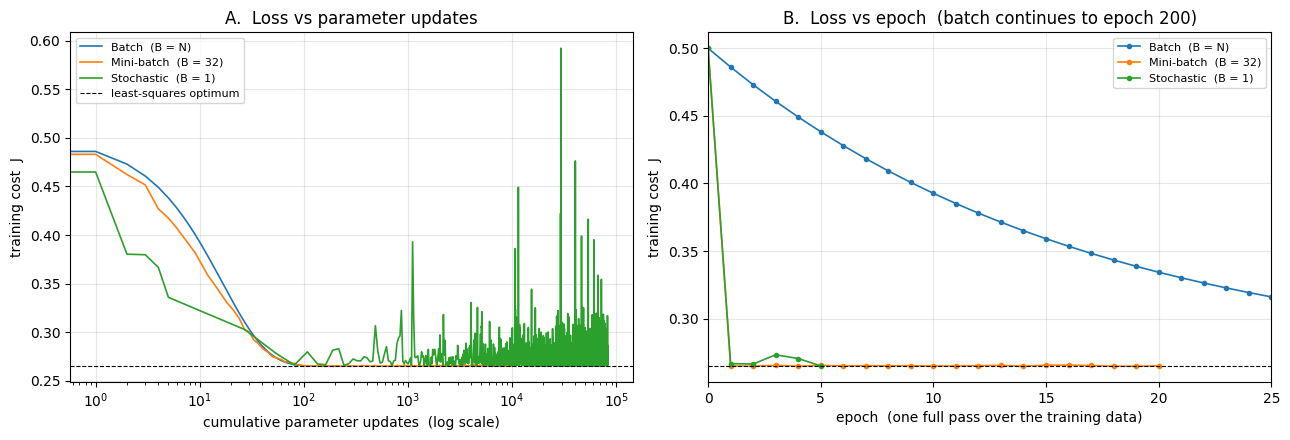

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

for name, h in runs.items():
    ax[0].plot(h["upd_idx"], h["update_loss"], label=name, lw=1.2)
ax[0].set_xscale("log")
ax[0].set_xlabel("cumulative parameter updates  (log scale)")
ax[0].set_ylabel("training cost  J")
ax[0].set_title("A.  Loss vs parameter updates")
ax[0].axhline(cost(x_tr, y_tr, [theta0_star, theta1_star]), ls="--", c="k", lw=0.8, label="least-squares optimum")
ax[0].legend(fontsize=8)
ax[0].grid(alpha=0.3)

for name, h in runs.items():
    ax[1].plot(range(h["n_epochs"] + 1), h["epoch_loss"], marker="o", ms=3, label=name, lw=1.2)
ax[1].set_xlim(0, 25)
ax[1].set_xlabel("epoch  (one full pass over the training data)")
ax[1].set_ylabel("training cost  J")
ax[1].set_title("B.  Loss vs epoch  (batch continues to epoch 200)")
ax[1].axhline(cost(x_tr, y_tr, [theta0_star, theta1_star]), ls="--", c="k", lw=0.8)
ax[1].legend(fontsize=8)
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Plot A (per update):** every batch step lands almost exactly on the smooth ideal
descent — it uses the whole dataset, so its gradient is the true gradient. Mini-batch
tracks it with a light wobble. SGD drops to the neighbourhood of the optimum in the
first few hundred updates (well under one epoch) and then **rattles around it and never
settles** — each step chases a single row, and with a constant $\alpha$ that noise
never shrinks.

**Plot B (per epoch):** the reason "just count epochs" is misleading. Mini-batch and
SGD are essentially done after 1–2 passes; batch has taken only 1–2 *steps* by then and
needs the better part of 200 epochs to arrive. Same algorithm — batch just gets far
fewer, far better steps per epoch.

### Plot C: the parameter trajectory on the loss surface

With only two parameters we can draw the cost as a contour map over
$(\theta_0, \theta_1)$ and trace the path each variant walks. This is the picture to
remember: **batch glides straight to the bottom, SGD stumbles toward it, mini-batch
takes a slightly wobbly but efficient line.**

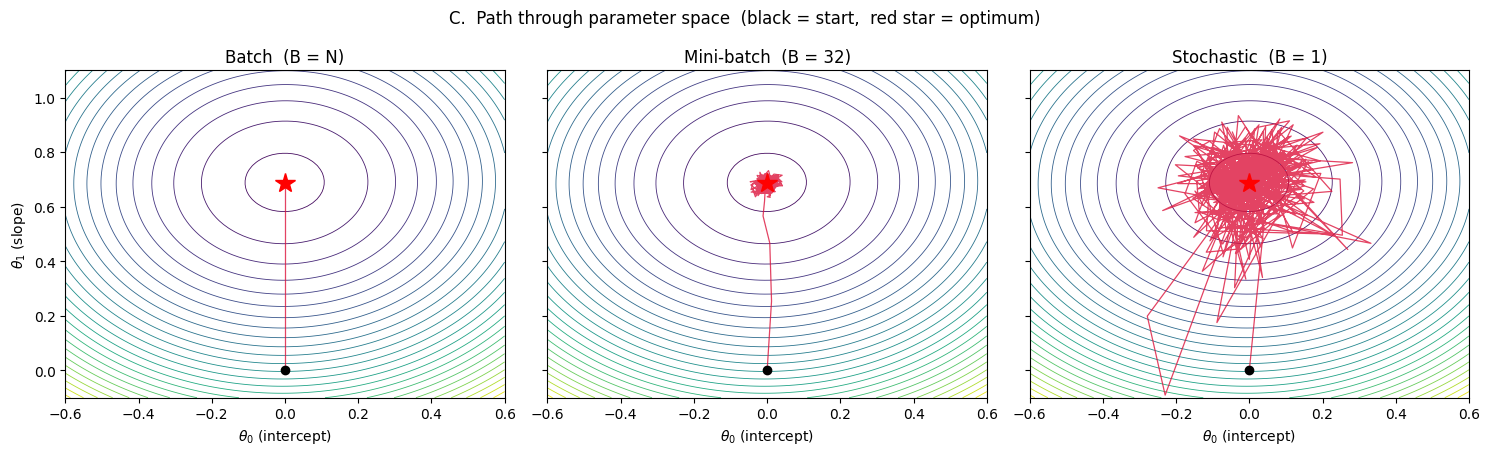

In [8]:
# cost surface over a grid of (theta0, theta1), vectorised over a 2k-row sample
xs_, ys_ = x_tr[:2000], y_tr[:2000]
g0 = np.linspace(-0.6, 0.6, 90)
g1 = np.linspace(-0.1, 1.1, 90)
G0, G1 = np.meshgrid(g0, g1)
resid = ys_[None, None, :] - (G0[..., None] + G1[..., None] * xs_[None, None, :])
Z = 0.5 * np.mean(resid**2, axis=2)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharex=True, sharey=True)
for ax, (name, h) in zip(axes, runs.items()):
    ax.contour(G0, G1, Z, levels=25, cmap="viridis", linewidths=0.6)
    th = h["theta"]
    step = max(1, len(th) // 400)          # subsample dense SGD path for clarity
    ax.plot(th[::step, 0], th[::step, 1], "-", lw=0.9, alpha=0.8, color="crimson")
    ax.plot(th[0, 0], th[0, 1], "ko", ms=6)
    ax.plot(theta0_star, theta1_star, "r*", ms=15)
    ax.set_title(name)
    ax.set_xlabel(r"$\theta_0$ (intercept)")
axes[0].set_ylabel(r"$\theta_1$ (slope)")
plt.suptitle("C.  Path through parameter space  (black = start,  red star = optimum)")
plt.tight_layout()
plt.show()

### Summary table

In [9]:
def updates_to_reach(h, tol):
    """Cumulative-update count at the first logged point with full-train loss <= tol."""
    hit = np.where(h["update_loss"] <= tol)[0]
    return int(h["upd_idx"][hit[0]]) if len(hit) else None

J_star = cost(x_tr, y_tr, [theta0_star, theta1_star])
tol = J_star * 1.05          # "within 5% of the optimum"

rows = []
for name, h in runs.items():
    late = h["upd_idx"] >= 0.9 * h["total_updates"]   # jitter over the final 10% of updates
    tail = h["update_loss"][late]
    rows.append({
        "variant": name,
        "updates/epoch": h["updates_per_epoch"],
        "total updates": h["total_updates"],
        "wall-clock (ms)": round(h["seconds"] * 1000, 1),
        "updates to reach 1.05*J*": updates_to_reach(h, tol),
        "final train J": round(cost(x_tr, y_tr, h["final_theta"]), 5),
        "final test J": round(cost(x_te, y_te, h["final_theta"]), 5),
        "tail-J std (jitter)": round(float(np.std(tail)), 6),
    })

pd.DataFrame(rows).set_index("variant")

,updates/epoch,total updates,wall-clock (ms),updates to reach 1.05*J*,final train J,final test J,tail-J std (jitter)
variant,,,,,,,
Batch (B = N),1,200,507.0,48,0.26481,0.24913,0.000001
Mini-batch (B = 32),516,10320,1217.0,48,0.26507,0.24905,0.000245
Stochastic (B = 1),16512,82560,4710.8,81,0.26505,0.24901,0.010103


Read the table with the plots:

- **updates/epoch** and **total updates** — the whole reason SGD "converges in fewer
  epochs": it simply takes N× more steps per epoch.
- **updates to reach 1.05·J\*** — batch gets within 5% of the optimum in the fewest
  *steps* (each step is the exact gradient), but those are 48 whole *epochs*;
  mini-batch and SGD get there in a fraction of one epoch.
- **wall-clock** — batch is fastest here (16k-row gradients vectorise well and it only
  needs a few hundred), SGD slowest (82k tiny Python-level steps). On data too large to
  fit in memory, or with a heavier per-row model, this ordering flips — that is exactly
  when mini-batch/SGD become necessary.
- **tail-J std** (jitter over the final 10% of updates) — the price of stochasticity:
  SGD keeps rattling (~0.009), mini-batch barely moves (~0.0003), batch is flat (~0).

---
# Part 5 — Two follow-ups

### 5.1  Sweep the batch size

Batch size is a dial, not three fixed options. Below, every setting gets the **same
budget of 10 epochs** (10 passes over the data). Small B → many cheap steps, reaches a
good fit; full-batch → only 10 steps total, barely moves; and the interesting result:
**mid-range B (128–1024) reaches essentially the best fit at the lowest wall-clock** —
few enough batches per epoch to be fast, large enough batches to step accurately.

In [10]:
sizes = [8, 32, 128, 1024, N]     # B = 1 is the "Stochastic" run from Part 4
sweep = []
for b in sizes:
    h = run_gd(x_tr, y_tr, batch_size=b, alpha=ALPHA, epochs=10, seed=0)
    sweep.append({"batch size": b,
                  "updates in 10 epochs": h["total_updates"],
                  "wall-clock (ms)": round(h["seconds"] * 1000, 1),
                  "final train J": round(cost(x_tr, y_tr, h["final_theta"]), 5),
                  "final test J": round(cost(x_te, y_te, h["final_theta"]), 5)})
pd.DataFrame(sweep).set_index("batch size")

,updates in 10 epochs,wall-clock (ms),final train J,final test J
batch size,,,,
8,20640,1463.6,0.26544,0.25045
32,5160,986.2,0.26497,0.24904
128,1290,269.2,0.26489,0.24901
1024,170,45.7,0.26483,0.24923
16512,10,14.7,0.39271,0.38028


### 5.2  SGD with a decaying learning rate

SGD's leftover jitter (the "tail-J std" column) comes from taking full-size steps on
single-row gradients forever. Shrinking $\alpha$ over time —
$\alpha_t = \alpha_0 / (1 + k\,t)$ — lets it take big steps early and settle quietly
later. This is the standard fix and the reason real SGD training uses a *learning-rate
schedule*.

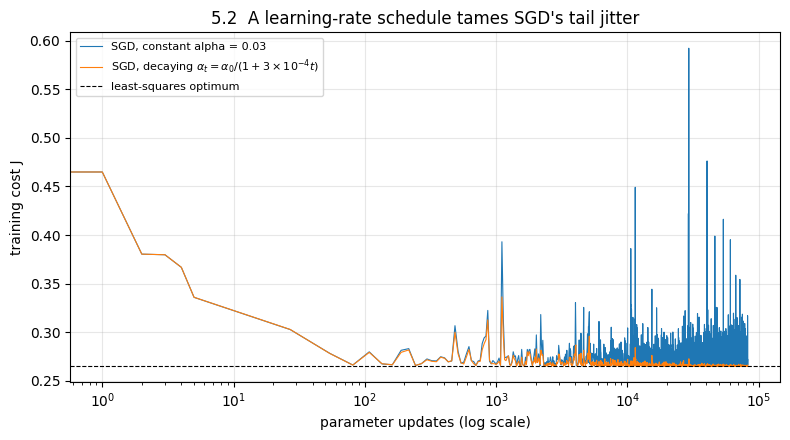

constant-alpha SGD  tail-J std: 0.009438
decaying-alpha SGD  tail-J std: 0.000259
constant-alpha final theta: (+0.0165, +0.6998)
decaying-alpha final theta: (+0.0200, +0.6483)
least-squares optimum:      (-0.0000, +0.6858)


In [11]:
def run_sgd_decay(x, y, alpha0, k, epochs, seed=0):
    r = np.random.default_rng(seed)
    theta = np.array([0.0, 0.0])
    n = len(x)
    log_every = max(1, (epochs * n) // 3000)
    idx, loss = [0], [cost(x, y, theta)]
    t = 0
    for _ in range(epochs):
        for i in r.permutation(n):
            theta = theta - (alpha0 / (1 + k * t)) * grad(x[[i]], y[[i]], theta)
            t += 1
            if t <= 5 or t % log_every == 0:
                idx.append(t)
                loss.append(cost(x, y, theta))
    return np.array(idx), np.array(loss), theta


sgd = runs["Stochastic  (B = 1)"]
d_idx, d_loss, decay_theta = run_sgd_decay(x_tr, y_tr, alpha0=ALPHA, k=3e-4, epochs=5, seed=0)

plt.figure(figsize=(8, 4.5))
plt.plot(sgd["upd_idx"], sgd["update_loss"], lw=0.8, label=f"SGD, constant alpha = {ALPHA}")
plt.plot(d_idx, d_loss, lw=0.8, label=r"SGD, decaying $\alpha_t = \alpha_0/(1+3\times10^{-4}t)$")
plt.axhline(J_star, ls="--", c="k", lw=0.8, label="least-squares optimum")
plt.xscale("log")
plt.xlabel("parameter updates (log scale)")
plt.ylabel("training cost J")
plt.title("5.2  A learning-rate schedule tames SGD's tail jitter")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"constant-alpha SGD  tail-J std: {np.std(sgd['update_loss'][-200:]):.6f}")
print(f"decaying-alpha SGD  tail-J std: {np.std(d_loss[-200:]):.6f}")
print(f"constant-alpha final theta: ({sgd['final_theta'][0]:+.4f}, {sgd['final_theta'][1]:+.4f})")
print(f"decaying-alpha final theta: ({decay_theta[0]:+.4f}, {decay_theta[1]:+.4f})")
print(f"least-squares optimum:      ({theta0_star:+.4f}, {theta1_star:+.4f})")

---
# Part 6 — Which one, when?

| | **Batch** | **Mini-batch** | **Stochastic** |
|---|---|---|---|
| Gradient per step | exact (all N rows) | good estimate (B rows) | noisy (1 row) |
| Updates per epoch | 1 | ⌈N/B⌉ | N |
| Cost per update | high | moderate | tiny |
| Trajectory | smooth, direct | slightly wobbly | jittery, hovers near optimum |
| Memory | must hold all N | holds B at a time | holds 1 |
| Vectorisation / GPU | wasteful (rare big steps) | **ideal** — B fills the hardware | underuses hardware |
| Data that doesn't fit in RAM | impossible | **works** (stream batches) | works |
| Converges to | exact optimum (convex) | near optimum, small jitter | near optimum, needs LR decay to settle |

**Rules of thumb**

- **Batch** — small datasets that fit comfortably in memory, or when you want a clean,
  reproducible descent for teaching/analysis. Rare in practice at scale.
- **Stochastic** — huge or streaming data, online learning where rows arrive one at a
  time; pair it with a learning-rate schedule.
- **Mini-batch** — the default for essentially all modern machine learning. It is the
  only one that both fits large data *and* uses vectorised hardware efficiently; B is
  usually 32–512. When someone says "SGD" for training a neural network, they almost
  always mean **mini-batch** SGD.

The loop never changed — predict, error, gradient, step. Only the number of rows
behind each step did, and that single dial trades gradient accuracy against steps
taken and hardware used.